# Профилирование rumor-walk-simulation (ветка dev)

Профилируются ключевые функции симуляции:
- `Simulator.step()` — один шаг (взаимодействия + перемещение агентов)
- `Simulator.run()` — полный прогон до исчезновения всех spreader'ов
- `Simulator.run_monte_carlo()` — серия независимых параллельных прогонов

**Состояния агентов (dev):** `ignorant`, `spreader`, `stifler`, `cooperator`  
**Параметры модели:** `spread_prob`, `stifle_prob`, `cooperate_prob`

## 1. Импорты и сборка симулятора

In [1]:
import cProfile
import pstats
import io
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from agent import Agent, State
from graph import ErdosRenyiGraph
from interaction_model import InteractionModel
from simulator import Simulator


def build_simulator(
    n: int,
    rng: np.random.Generator,
    p: float,
    spread_prob: float,
    stifle_prob: float,
    cooperate_prob: float,
) -> tuple[Simulator, ErdosRenyiGraph]:
    """Сборка симулятора — сигнатура совпадает с main.py (ветка dev)."""
    graph = ErdosRenyiGraph.generate(n, p, rng)
    agents = [Agent(State.ignorant, int(rng.integers(0, n - 1))) for _ in range(n)]
    agents[0].state = State.spreader
    node_occupants = {i: [] for i in range(n)}
    for a in agents:
        node_occupants[a.position].append(a)
    model = InteractionModel(
        spread_prob=spread_prob,
        stifle_prob=stifle_prob,
        cooperate_prob=cooperate_prob,
        rng=rng,
    )
    sim = Simulator(
        agents=agents,
        graph=graph,
        node_occupants=node_occupants,
        interaction_model=model,
        rng=rng,
    )
    return sim, graph


# Параметры по умолчанию
RNG_SEED    = 42
P_EDGE      = 0.9
SPREAD_PROB = 0.5
STIFLE_PROB = 0.3
COOP_PROB   = 0.1

sim_small,  graph_small  = build_simulator(20,  np.random.default_rng(RNG_SEED), P_EDGE, SPREAD_PROB, STIFLE_PROB, COOP_PROB)
sim_medium, graph_medium = build_simulator(100, np.random.default_rng(RNG_SEED), P_EDGE, SPREAD_PROB, STIFLE_PROB, COOP_PROB)

print(f"Малый симулятор:   {len(sim_small.agents)} агентов")
print(f"Средний симулятор: {len(sim_medium.agents)} агентов")
print(f"Ключи stats (dev): {list(sim_small.collect.__doc__ and ['tick','ignorant','spreader','stifler','cooperator'])}")

Малый симулятор:   20 агентов
Средний симулятор: 100 агентов
Ключи stats (dev): ['tick', 'ignorant', 'spreader', 'stifler', 'cooperator']


## 2. Профилирование `step()` — один шаг симуляции

Запускаем 50 шагов подряд, чтобы накопить достаточно вызовов для анализа.

In [2]:
N_STEPS = 50

sim_step, _ = build_simulator(20, np.random.default_rng(1), P_EDGE, SPREAD_PROB, STIFLE_PROB, COOP_PROB)
for a in sim_step.agents:
    a.state = State.spreader

pr_step = cProfile.Profile()
pr_step.enable()

for _ in range(N_STEPS):
    sim_step.step()

pr_step.disable()

buf = io.StringIO()
pstats.Stats(pr_step, stream=buf).sort_stats('cumulative').print_stats(15)
print(buf.getvalue())

         22972 function calls (22965 primitive calls) in 0.061 seconds

   Ordered by: cumulative time
   List reduced from 125 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/2    0.023    0.008    0.027    0.014 /home/aleksei/rum-new/rumor-walk-simulation/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3712(run_code)
       50    0.014    0.000    0.026    0.001 /home/aleksei/rum-new/rumor-walk-simulation/simulator.py:76(step)
      3/2    0.000    0.000    0.023    0.012 /usr/lib/python3.12/asyncio/events.py:86(_run)
        2    0.000    0.000    0.023    0.011 {method 'run' of '_contextvars.Context' objects}
        2    0.000    0.000    0.023    0.011 /home/aleksei/rum-new/rumor-walk-simulation/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:573(_handle_events)
        1    0.000    0.000    0.023    0.023 /home/aleksei/rum-new/rumor-walk-simulation/.venv/lib/python3.12/site-packages

## 3. Профилирование `run()` — полный прогон

In [3]:
sim_run, _ = build_simulator(100, np.random.default_rng(2), P_EDGE, SPREAD_PROB, STIFLE_PROB, COOP_PROB)

pr_run = cProfile.Profile()
pr_run.enable()

sim_run.run()

pr_run.disable()

buf = io.StringIO()
pstats.Stats(pr_run, stream=buf).sort_stats('cumulative').print_stats(15)
print(buf.getvalue())

last_stat = sim_run.stats[-1]
print(f"Симуляция завершилась за {len(sim_run.stats)} тиков")
print(f"Финальное состояние: ignorant={last_stat['ignorant']}, "
      f"spreader={last_stat['spreader']}, stifler={last_stat['stifler']}, "
      f"cooperator={last_stat['cooperator']}")

         466926 function calls (419912 primitive calls) in 0.282 seconds

   Ordered by: cumulative time
   List reduced from 219 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        3    0.000    0.000    0.239    0.080 /usr/lib/python3.12/asyncio/base_events.py:1910(_run_once)
        1    0.000    0.000    0.239    0.239 /usr/lib/python3.12/threading.py:637(wait)
       47    0.002    0.000    0.169    0.004 /home/aleksei/rum-new/rumor-walk-simulation/simulator.py:44(collect)
 42347/47    0.067    0.000    0.165    0.004 /usr/lib/python3.12/copy.py:118(deepcopy)
  4747/47    0.015    0.000    0.165    0.004 /usr/lib/python3.12/copy.py:217(_deepcopy_dict)
     4700    0.006    0.000    0.140    0.000 /usr/lib/python3.12/copy.py:191(_deepcopy_list)
       47    0.058    0.001    0.104    0.002 /home/aleksei/rum-new/rumor-walk-simulation/simulator.py:76(step)
     4700    0.015    0.000    0.101    0.000 /usr/lib/python3.12/copy

## 4. Профилирование `run_monte_carlo()` — параллельные прогоны

In [4]:
N_MC_RUNS = 10

sim_mc, _ = build_simulator(50, np.random.default_rng(3), P_EDGE, SPREAD_PROB, STIFLE_PROB, COOP_PROB)

t0 = time.perf_counter()

pr_mc = cProfile.Profile()
pr_mc.enable()

mc_results = sim_mc.run_monte_carlo(N_MC_RUNS)

pr_mc.disable()
t1 = time.perf_counter()

buf = io.StringIO()
pstats.Stats(pr_mc, stream=buf).sort_stats('cumulative').print_stats(15)
print(buf.getvalue())

print(f"run_monte_carlo({N_MC_RUNS} runs, n=50): {t1 - t0:.3f} сек")

sample_stat = mc_results[0][-1]
print(f"Ключи в stats: {list(sample_stat.keys())}")

         14709 function calls (14396 primitive calls) in 0.258 seconds

   Ordered by: cumulative time
   List reduced from 498 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
  277/170    0.003    0.000    0.164    0.001 {method 'acquire' of '_thread.lock' objects}
    75/74    0.000    0.000    0.164    0.002 /usr/lib/python3.12/threading.py:1153(_wait_for_tstate_lock)
      3/2    0.000    0.000    0.163    0.082 /usr/lib/python3.12/threading.py:1115(join)
        1    0.000    0.000    0.162    0.162 /usr/lib/python3.12/concurrent/futures/_base.py:646(__exit__)
        1    0.000    0.000    0.162    0.162 /usr/lib/python3.12/concurrent/futures/process.py:864(shutdown)
      2/1    0.000    0.000    0.161    0.161 /usr/lib/python3.12/threading.py:1016(_bootstrap)
      2/1    0.000    0.000    0.161    0.161 /usr/lib/python3.12/threading.py:1056(_bootstrap_inner)
        1    0.000    0.000    0.161    0.161 /usr/lib/python3.12

## 5. Динамика состояний агентов (один прогон)

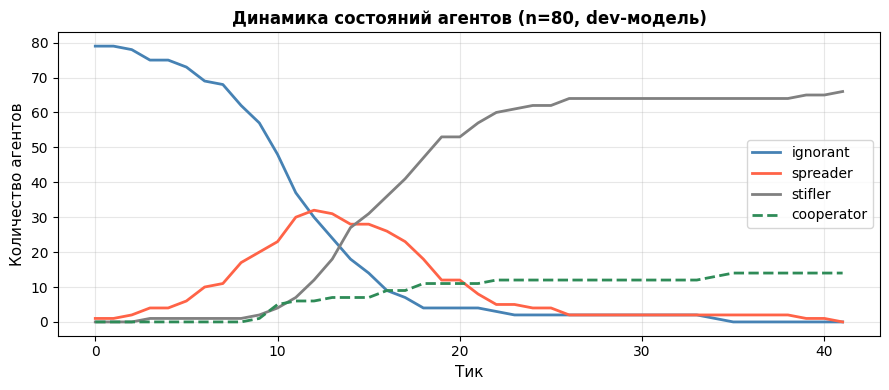

График сохранён: dynamics.png


In [5]:
sim_plot, _ = build_simulator(80, np.random.default_rng(7), P_EDGE, SPREAD_PROB, STIFLE_PROB, COOP_PROB)
sim_plot.run()

ticks      = [s['tick']      for s in sim_plot.stats]
ignorants  = [s['ignorant']  for s in sim_plot.stats]
spreaders  = [s['spreader']  for s in sim_plot.stats]
stiflers   = [s['stifler']   for s in sim_plot.stats]
cooperators = [s['cooperator'] for s in sim_plot.stats]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ticks, ignorants,   label='ignorant',   color='steelblue',  linewidth=2)
ax.plot(ticks, spreaders,   label='spreader',   color='tomato',     linewidth=2)
ax.plot(ticks, stiflers,    label='stifler',    color='gray',       linewidth=2)
ax.plot(ticks, cooperators, label='cooperator', color='seagreen',   linewidth=2, linestyle='--')
ax.set_xlabel('Тик', fontsize=11)
ax.set_ylabel('Количество агентов', fontsize=11)
ax.set_title('Динамика состояний агентов (n=80, dev-модель)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dynamics.png', dpi=120, bbox_inches='tight')
plt.show()
print("График сохранён: dynamics.png")

## 6. Сравнительный барчарт: топ функций по cumtime

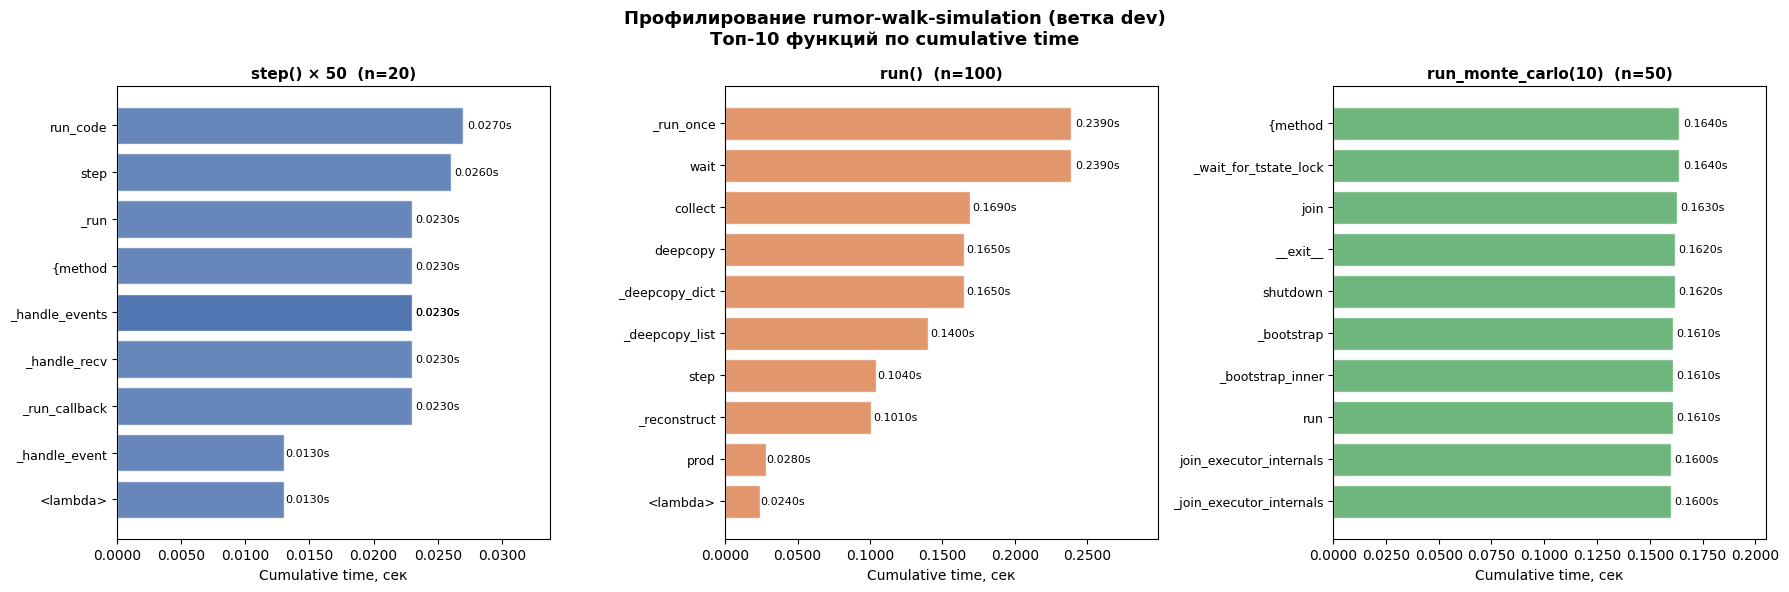

График сохранён: profiling_results.png


In [6]:
def extract_top_stats(profiler: cProfile.Profile, top_n: int = 10):
    """Извлекает топ-N функций из профилировщика по cumulative time."""
    buf = io.StringIO()
    pstats.Stats(profiler, stream=buf).sort_stats('cumulative').print_stats(top_n)
    names, cumtimes = [], []
    for line in buf.getvalue().splitlines():
        parts = line.strip().split()
        if len(parts) >= 6 and parts[0].replace('/', '').isdigit():
            try:
                cumtime = float(parts[3])
                func_name = parts[5].split('(')[-1].rstrip(')')
                if func_name not in ('None', '', '{built-in'):
                    names.append(func_name)
                    cumtimes.append(cumtime)
            except (ValueError, IndexError):
                continue
    return names[:top_n], cumtimes[:top_n]


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Профилирование rumor-walk-simulation (ветка dev)\nТоп-10 функций по cumulative time',
    fontsize=13, fontweight='bold'
)

configs = [
    (pr_step, f'step() × {N_STEPS}  (n=20)',         axes[0], '#4C72B0'),
    (pr_run,  'run()  (n=100)',                       axes[1], '#DD8452'),
    (pr_mc,   f'run_monte_carlo({N_MC_RUNS})  (n=50)', axes[2], '#55A868'),
]

for profiler, title, ax, color in configs:
    names, cumtimes = extract_top_stats(profiler, top_n=10)
    if not names:
        ax.set_title(f'{title}\n(нет данных)')
        continue
    names_r, cumtimes_r = names[::-1], cumtimes[::-1]
    bars = ax.barh(names_r, cumtimes_r, color=color, alpha=0.85, edgecolor='white')
    ax.set_xlabel('Cumulative time, сек', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
    for bar, val in zip(bars, cumtimes_r):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}s', va='center', fontsize=8)
    ax.set_xlim(0, max(cumtimes_r) * 1.25)
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('profiling_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("График сохранён: profiling_results.png")

## 7. Масштабируемость run() по размеру сети

n=  10: 0.0035 сек  (22 тиков)
n=  20: 0.0048 сек  (26 тиков)
n=  50: 0.1414 сек  (36 тиков)
n= 100: 0.0302 сек  (30 тиков)


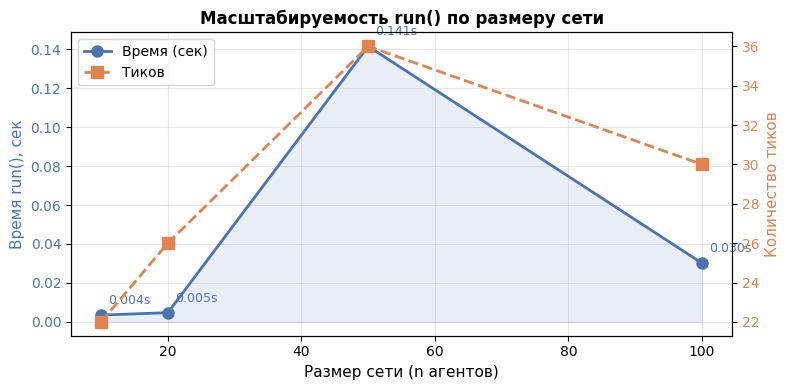

График сохранён: scaling_results.png


In [7]:
sizes  = [10, 20, 50, 100]
times  = []
n_ticks = []

for n in sizes:
    sim, _ = build_simulator(n, np.random.default_rng(42), P_EDGE, SPREAD_PROB, STIFLE_PROB, COOP_PROB)
    t0 = time.perf_counter()
    sim.run()
    elapsed = time.perf_counter() - t0
    times.append(elapsed)
    n_ticks.append(len(sim.stats))
    print(f"n={n:4d}: {elapsed:.4f} сек  ({n_ticks[-1]} тиков)")

fig, ax1 = plt.subplots(figsize=(8, 4))
color1, color2 = '#4C72B0', '#DD8452'

ax1.plot(sizes, times, marker='o', color=color1, linewidth=2, markersize=8, label='Время (сек)')
ax1.fill_between(sizes, times, alpha=0.12, color=color1)
ax1.set_xlabel('Размер сети (n агентов)', fontsize=11)
ax1.set_ylabel('Время run(), сек', fontsize=11, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(sizes, n_ticks, marker='s', color=color2, linewidth=2, markersize=8,
         linestyle='--', label='Тиков')
ax2.set_ylabel('Количество тиков', fontsize=11, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title('Масштабируемость run() по размеру сети', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper left')

for x, y in zip(sizes, times):
    ax1.annotate(f'{y:.3f}s', (x, y), textcoords='offset points', xytext=(5, 8), fontsize=9, color=color1)

plt.tight_layout()
plt.savefig('scaling_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("График сохранён: scaling_results.png")

## 8. Выводы

### Узкие места (bottlenecks)

**`step()` — взаимодействия:**
- Основная нагрузка — `itertools.combinations()`: перебор всех пар агентов на одном узле. Сложность O(k²) где k — агентов на узле.
- При плотном графе (высокое p) агенты концентрируются в меньшем числе узлов → k растёт → время растёт нелинейно.
- Второй по весу вызов — `rng.random()` из numpy внутри `interact()` — генерация случайных чисел.

**`collect()` — сбор статистики:**
- Python-цикл `for agent in self.agents` с 4 ветками `if/elif` + `copy.deepcopy(self.node_occupants)` для снапшота.
- `deepcopy` дорог: при n=100 агентах каждый тик создаёт полную копию словаря с объектами.

**`run_monte_carlo()` — параллельность:**
- Использует `ProcessPoolExecutor` → реальное ускорение на многоядерных машинах.
- Накладные расходы: сериализация (pickle) симулятора при передаче в subprocess заметна при малом n.


### Возможные оптимизации

| Место | Проблема | Оптимизация |
|---|---|---|
| `step()` → `combinations()` | O(k²) пар на узел | Выбирать одну случайную пару вместо всех → O(1) |
| `collect()` → `deepcopy` | Полная копия node_occupants каждый тик | Отключать снапшоты если визуализация не нужна |
| `collect()` → цикл | Python-цикл по всем агентам | Заменить на `numpy` счётчик по массиву состояний |
| `get_neighbors()` | Вызов словаря на каждом шаге каждого агента | Кешировать список соседей в numpy-массив при инициализации |
| `run_monte_carlo()` | Pickle-overhead при малом n | При малом n использовать `ThreadPoolExecutor` вместо `ProcessPoolExecutor` |